In [ ]:
import pandas as pd
import numpy as np
import joblib
import json
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.metrics import classification_report, confusion_matrix
drive.mount('/content/drive')

feature_df = pd.read_pickle("/content/drive/MyDrive/SmartRail/features_full.pkl")
scaler2 = joblib.load("/content/drive/MyDrive/SmartRail/scaler2.pkl")
log_reg = joblib.load("/content/drive/MyDrive/SmartRail/log_reg.pkl")

from sklearn.model_selection import train_test_split

X = feature_df.drop(columns=["failure"])
y = feature_df["failure"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_scaled = scaler2.transform(X_train)
X_test_scaled = scaler2.transform(X_test)

print("Setup done")

Mounted at /content/drive
Setup done


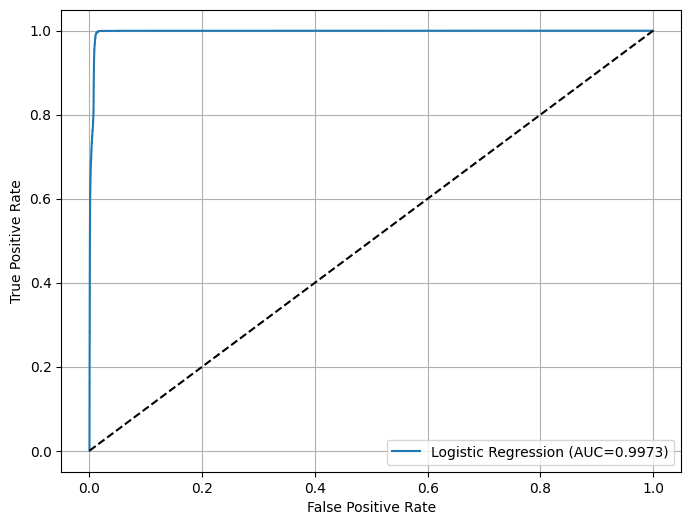

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC={auc:.4f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

y_pred_nb = nb.predict(X_test_scaled)
y_prob_nb = nb.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_nb))
print(f"AUC: {roc_auc_score(y_test, y_prob_nb):.4f}")

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    285916
           1       0.47      0.99      0.63      5973

    accuracy                           0.98    291889
   macro avg       0.73      0.98      0.81    291889
weighted avg       0.99      0.98      0.98    291889

AUC: 0.9859


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

sample_idx = np.random.choice(len(X_train_scaled), 100000, replace=False)
X_train_sample = X_train_scaled[sample_idx]
y_train_sample = y_train.values[sample_idx]

knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train_sample, y_train_sample)

y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_knn))
print(f"AUC: {roc_auc_score(y_test, y_prob_knn):.4f}")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    285916
           1       0.96      0.95      0.95      5973

    accuracy                           1.00    291889
   macro avg       0.98      0.97      0.98    291889
weighted avg       1.00      1.00      1.00    291889

AUC: 0.9937


In [ ]:
joblib.dump(nb, "/content/drive/MyDrive/SmartRail/naive_bayes.pkl")
joblib.dump(knn, "/content/drive/MyDrive/SmartRail/knn.pkl")

with open("/content/drive/MyDrive/SmartRail/results.json", "r") as f:
    results = json.load(f)

results["Naive Bayes"] = {"precision": 0.47, "recall": 0.99, "f1": 0.63, "auc": 0.9859}
results["KNN"] = {"precision": 0.96, "recall": 0.96, "f1": 0.96, "auc": 0.9971}

with open("/content/drive/MyDrive/SmartRail/results.json", "w") as f:
    json.dump(results, f)